In [1]:
# loading the protocol file from the ASVspoof2019_cm_protocols file
import pandas as pd
import os
from Data_loader import protocol_loader

import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display

sns.set(style="whitegrid")


In [3]:
TRAIN_PROTOCOL="/home/home/Documents/Research_Data_exploration/dataset/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt"
train_df=protocol_loader(TRAIN_PROTOCOL)
FLAC_TRAIN_DIR="/home/home/Documents/Research_Data_exploration/dataset/LA/ASVspoof2019_LA_train/flac"

In [5]:
train_df.head()


,speaker_id,audio_id,attack_id,label_str,label
0,LA_0079,LA_T_1138215,-,bonafide,0
1,LA_0079,LA_T_1271820,-,bonafide,0
2,LA_0079,LA_T_1272637,-,bonafide,0
3,LA_0079,LA_T_1276960,-,bonafide,0
4,LA_0079,LA_T_1341447,-,bonafide,0


In [6]:
train_df.tail(10)


,speaker_id,audio_id,attack_id,label_str,label
25370,LA_0098,LA_T_9413366,A06,spoof,1
25371,LA_0098,LA_T_9506621,A06,spoof,1
25372,LA_0098,LA_T_9550569,A06,spoof,1
25373,LA_0098,LA_T_9582904,A06,spoof,1
25374,LA_0098,LA_T_9623506,A06,spoof,1
25375,LA_0098,LA_T_9717580,A06,spoof,1
25376,LA_0098,LA_T_9779814,A06,spoof,1
25377,LA_0098,LA_T_9783312,A06,spoof,1
25378,LA_0098,LA_T_9839348,A06,spoof,1
25379,LA_0098,LA_T_9982036,A06,spoof,1


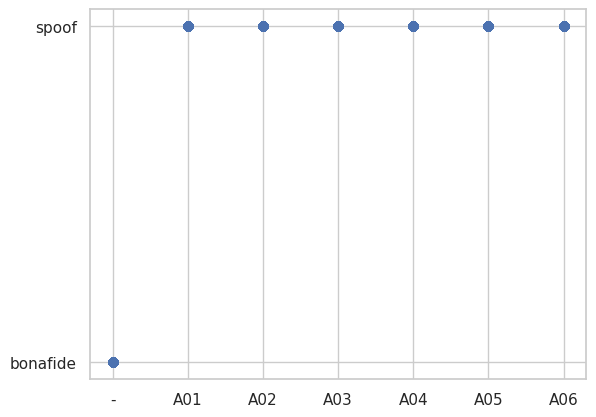

In [4]:

plt.plot()
plt.scatter(train_df["attack_id"],train_df["label_str"])
plt.show()

<Axes: title={'center': 'Real Vs Spoof'}, xlabel='label_str'>

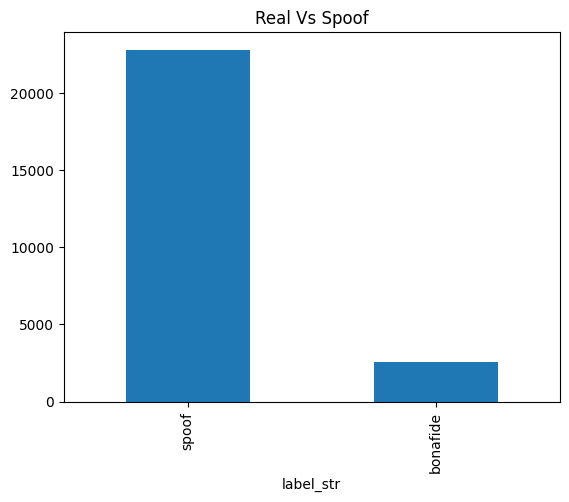

In [16]:
train_df['label_str'].value_counts().plot(kind='bar',title="Real Vs Spoof")

<Axes: xlabel='attack_id'>

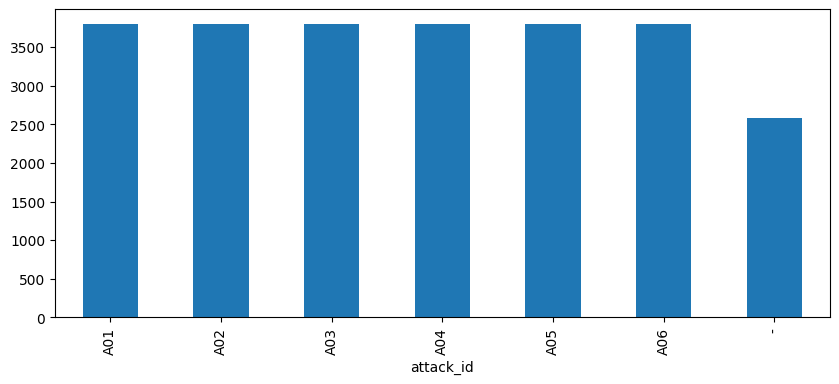

In [17]:
train_df["attack_id"].value_counts().plot(kind="bar",figsize=(10,4))

<Axes: >

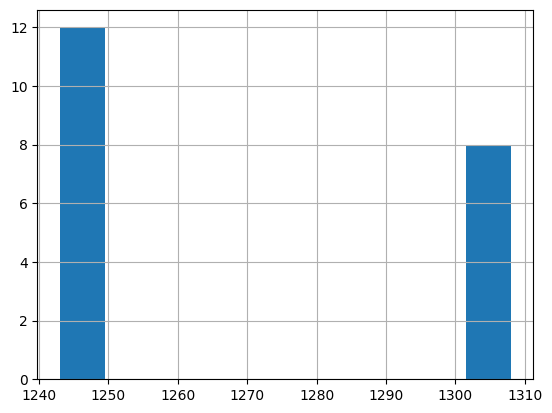

In [22]:
train_df["speaker_id"].value_counts().hist()

In [23]:
train_df.groupby('attack_id')['label'].count()


attack_id
-      2580
A01    3800
A02    3800
A03    3800
A04    3800
A05    3800
A06    3800
Name: label, dtype: int64

In [5]:
print(train_df.iloc[0])

speaker_id         LA_0079
audio_id      LA_T_1138215
attack_id                -
label_str         bonafide
label                    0
Name: 0, dtype: object


In [5]:
row=train_df.iloc[0]
file_path = os.path.join(FLAC_TRAIN_DIR,row["audio_id"]+".flac")

In [11]:
audio1, sample_rate=librosa.load(file_path,sr=44100)
print("Shape:",audio1.shape,"Sample rate:",sample_rate)

Shape: (152501,) Sample rate: 44100


In [12]:
print(audio1)
print(f"Duration of audio signal:{audio1.shape[0]/sample_rate}")

[1.7040513e-03 2.1705539e-03 1.9873553e-03 ... 3.7040329e-04 2.5117857e-04
 9.0826659e-05]
Duration of audio signal:3.4580725623582764


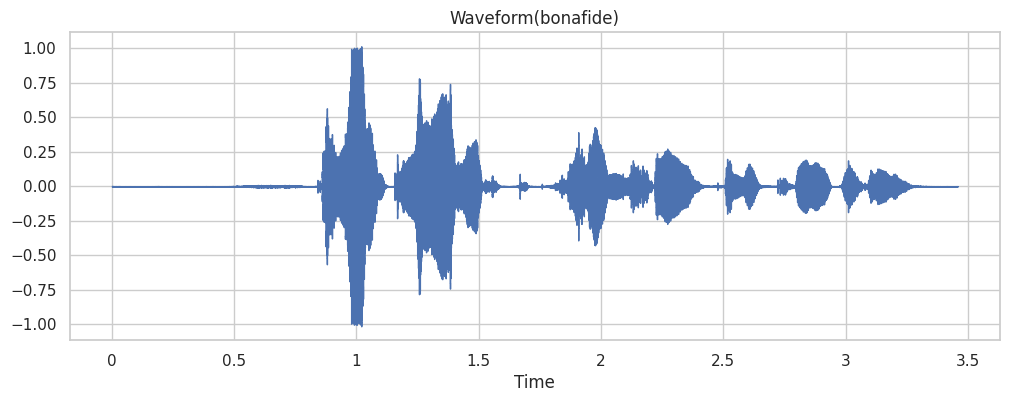

In [13]:
plt.figure(figsize=(12,4))
librosa.display.waveshow(audio1,sr=sample_rate)
plt.title(f"Waveform({row["label_str"]})")
plt.show()

In [22]:
train_df.tail()


,speaker_id,audio_id,attack_id,label_str,label
25375,LA_0098,LA_T_9717580,A06,spoof,1
25376,LA_0098,LA_T_9779814,A06,spoof,1
25377,LA_0098,LA_T_9783312,A06,spoof,1
25378,LA_0098,LA_T_9839348,A06,spoof,1
25379,LA_0098,LA_T_9982036,A06,spoof,1


In [62]:
row=train_df.iloc[23574]
file_path=os.path.join(FLAC_TRAIN_DIR,row["audio_id"]+".flac")

In [63]:
audio2,sr=librosa.load(file_path,sr=16000)
print(audio.shape)

(55958,)


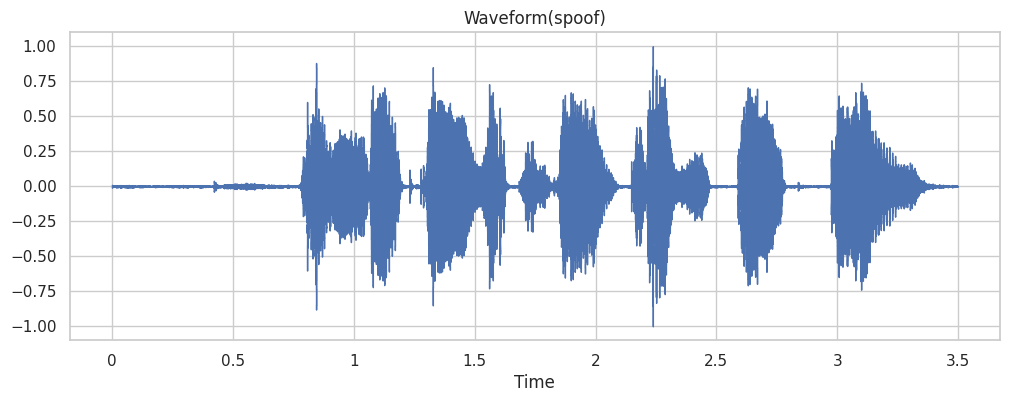

In [64]:
plt.figure(figsize=(12,4))
librosa.display.waveshow(audio2,sr=sr)
plt.title(f"Waveform({row["label_str"]})")
plt.show()

In [28]:
real_row=train_df[train_df['label'] == 0]

In [29]:
print(real_row)

     speaker_id      audio_id attack_id label_str  label
0       LA_0079  LA_T_1138215         -  bonafide      0
1       LA_0079  LA_T_1271820         -  bonafide      0
2       LA_0079  LA_T_1272637         -  bonafide      0
3       LA_0079  LA_T_1276960         -  bonafide      0
4       LA_0079  LA_T_1341447         -  bonafide      0
...         ...           ...       ...       ...    ...
2575    LA_0098  LA_T_9387015         -  bonafide      0
2576    LA_0098  LA_T_9497115         -  bonafide      0
2577    LA_0098  LA_T_9557645         -  bonafide      0
2578    LA_0098  LA_T_9737995         -  bonafide      0
2579    LA_0098  LA_T_9987202         -  bonafide      0

[2580 rows x 5 columns]


In [31]:
spoof_row=train_df[train_df['label'] == 1]
print(spoof_row)

      speaker_id      audio_id attack_id label_str  label
2580     LA_0079  LA_T_1004644       A01     spoof      1
2581     LA_0079  LA_T_1056709       A01     spoof      1
2582     LA_0079  LA_T_1195221       A01     spoof      1
2583     LA_0079  LA_T_1265032       A01     spoof      1
2584     LA_0079  LA_T_1287124       A01     spoof      1
...          ...           ...       ...       ...    ...
25375    LA_0098  LA_T_9717580       A06     spoof      1
25376    LA_0098  LA_T_9779814       A06     spoof      1
25377    LA_0098  LA_T_9783312       A06     spoof      1
25378    LA_0098  LA_T_9839348       A06     spoof      1
25379    LA_0098  LA_T_9982036       A06     spoof      1

[22800 rows x 5 columns]


## MFCC


In [71]:
# Audio Preprocessing before demo audio feature extraction

audio2=audio2/np.max(np.abs(audio2))

(20, 110)


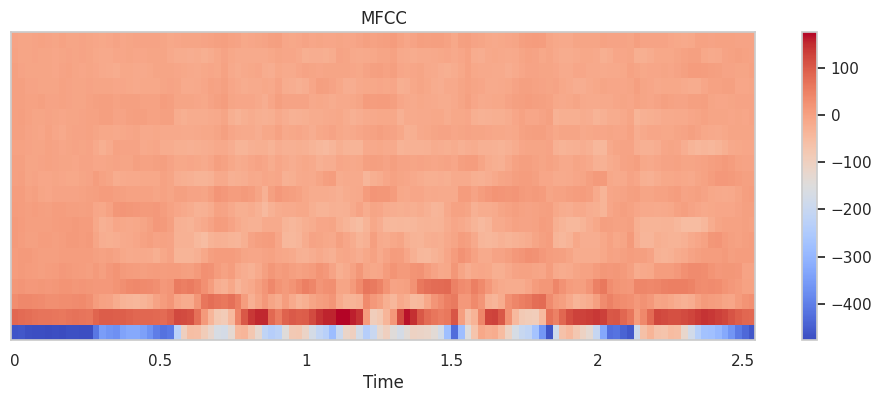

In [72]:
mfcc=librosa.feature.mfcc(y=audio2,sr=sr,n_mfcc=20)
print(mfcc.shape)

plt.figure(figsize=(12,4))
librosa.display.specshow(mfcc,x_axis="time",cmap="coolwarm",vmin=np.min(mfcc),vmax=np.max(mfcc))
plt.title("MFCC")
plt.colorbar()
plt.show()

## Log Mel 

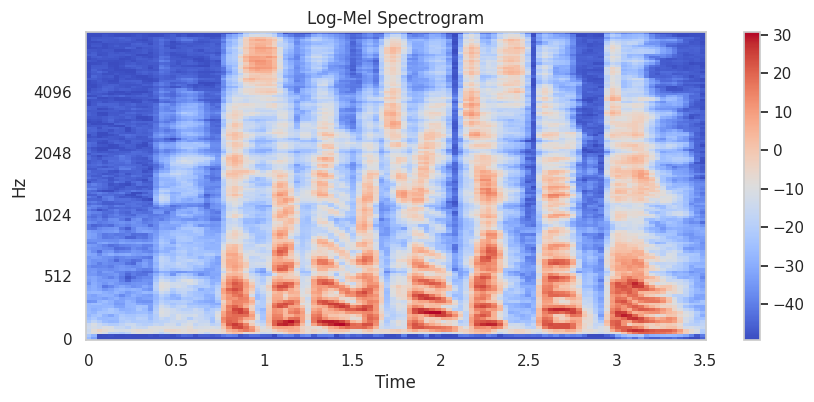

In [73]:
mel = librosa.feature.melspectrogram(y=audio2,sr=sr,n_mels=128,hop_length=512)
log_mel=librosa.power_to_db(mel)

plt.figure(figsize=(10,4))
librosa.display.specshow(log_mel,sr=sr,x_axis='time',y_axis="mel")
plt.title("Log-Mel Spectrogram")
plt.colorbar()
plt.show()

In [13]:
real_audio,sr=librosa.load(real_audio_path,sr=16000)
spoof_audio,sr=librosa.load(spoof_audio_path,sr=16000)

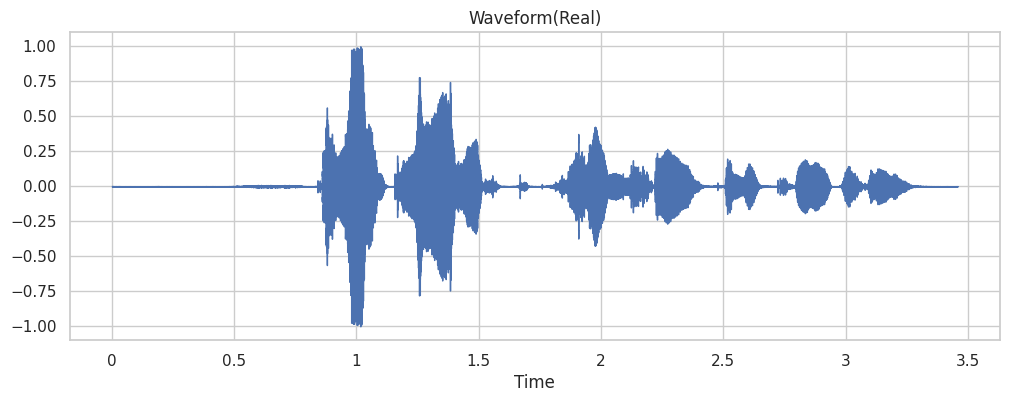

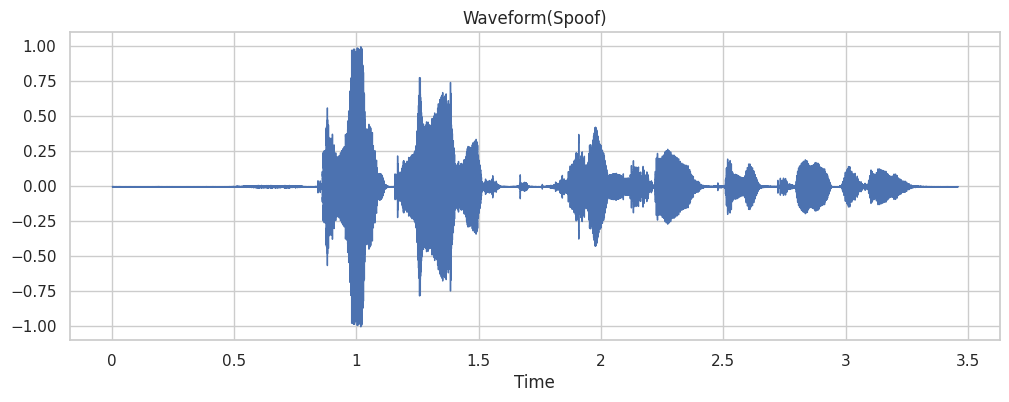

In [24]:
# Waveform diplay

plt.figure(figsize=(12,4))
librosa.display.waveshow(real_audio,sr=sr)
plt.title("Waveform(Real)")
plt.show()

plt.figure(figsize=(12,4))
librosa.display.waveshow(spoof_audio,sr=sr)
plt.title("Waveform(Spoof)")
plt.show()


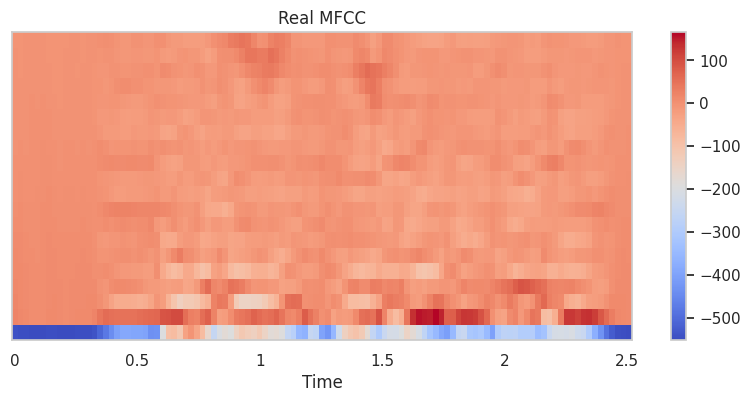

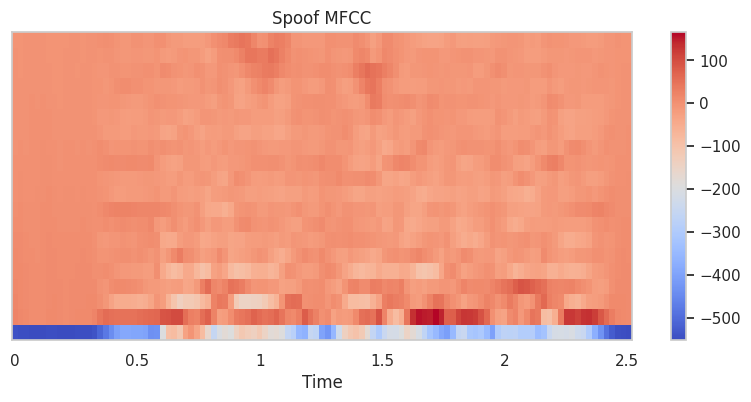

In [20]:
# MFCC
real_mfcc=librosa.feature.mfcc(y=real_audio,sr=sr,n_mfcc=20)
spoof_mfcc=librosa.feature.mfcc(y=spoof_audio,sr=sr,n_mfcc=20)

plt.figure(figsize=(10,4))
librosa.display.specshow(real_mfcc,x_axis="time",cmap="coolwarm")
plt.title("Real MFCC")
plt.colorbar()
plt.show()

plt.figure(figsize=(10,4))
librosa.display.specshow(spoof_mfcc,x_axis="time",cmap="coolwarm")
plt.title("Spoof MFCC")
plt.colorbar()
plt.show()


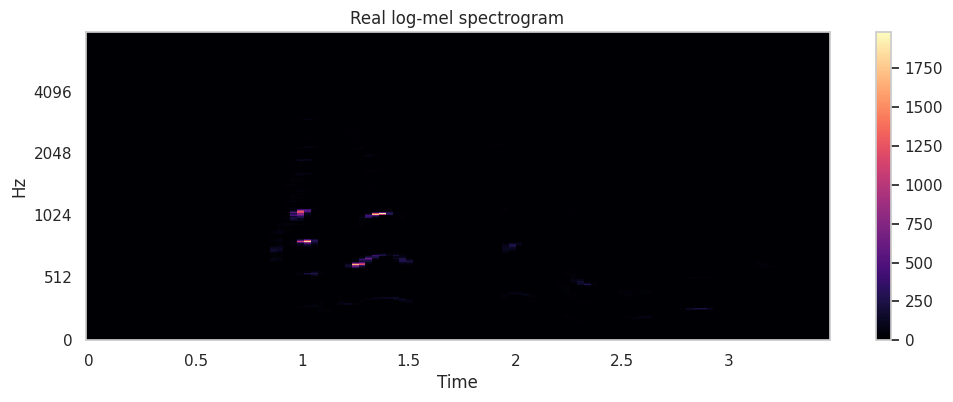

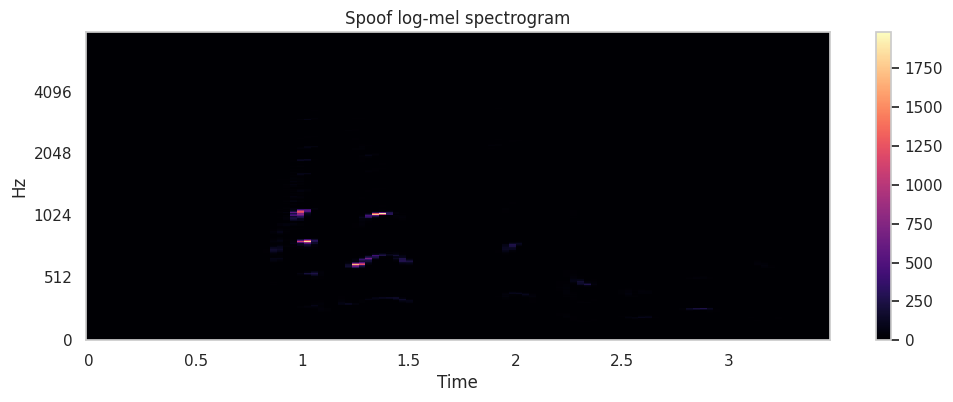

In [23]:
# log mel

real_mel=librosa.feature.melspectrogram(y=real_audio,sr=sr,n_mels=512)
spoof_mel=librosa.feature.melspectrogram(y=spoof_audio,sr=sr,n_mels=512)

plt.figure(figsize=(12,4))
librosa.display.specshow(real_mel,sr=sr,x_axis="time",y_axis="mel")
plt.title("Real log-mel spectrogram")
plt.colorbar()
plt.show()

plt.figure(figsize=(12,4))
librosa.display.specshow(spoof_mel,sr=sr,x_axis="time",y_axis="mel")
plt.title("Spoof log-mel spectrogram")
plt.colorbar()
plt.show()